# SECTION 1 — Environment Setup

# Heart Disease Classification Experiment

This notebook evaluates the performance of:

- Single classifiers
- CombinedClassifier aggregation

on the Heart Disease dataset.

Metrics:
- Accuracy
- F1-score
- Precision
- Recall

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from functools import wraps
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)


def evaluate_classification(
    y_true,
    y_pred,
    y_prob=None,
    average="weighted",
    return_confusion_matrix=False,
):
    """
    Evaluate classification predictions.

    Parameters
    ----------
    y_true : array-like
        Ground truth labels.

    y_pred : array-like
        Predicted labels.

    y_prob : array-like, optional
        Prediction probabilities for ROC-AUC.

    average : str, default="weighted"
        Averaging method for multiclass metrics.

    return_confusion_matrix : bool, default=False
        Whether to include confusion matrix.

    Returns
    -------
    dict
        Dictionary containing evaluation metrics.
    """

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),

        "Precision": precision_score(
            y_true,
            y_pred,
            average=average,
            zero_division=0,
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            average=average,
            zero_division=0,
        ),

        "F1 Score": f1_score(
            y_true,
            y_pred,
            average=average,
            zero_division=0,
        ),
    }

    # ROC-AUC
    if y_prob is not None:
        try:
            metrics["ROC AUC"] = roc_auc_score(y_true, y_prob)
        except Exception:
            pass

    # Confusion Matrix
    if return_confusion_matrix:
        metrics["Confusion Matrix"] = confusion_matrix(
            y_true,
            y_pred,
        )

    return metrics

def timeit(unit="seconds"):
    """
    Decorator for measuring execution time.

    Parameters
    ----------
    unit : str, default="seconds"
        Time unit:
        - "seconds"
        - "milliseconds"
        - "minutes"
    """

    UNIT_DIVISORS = {
        "seconds": 1,
        "milliseconds": 1000,
        "minutes": 1 / 60,
    }

    if unit not in UNIT_DIVISORS:
        raise ValueError(
            f"Unsupported unit: {unit}"
        )

    def decorator(func):

        @wraps(func)
        def wrapper(*args, **kwargs):

            start_time = time.perf_counter()

            result = func(*args, **kwargs)

            end_time = time.perf_counter()

            elapsed = (
                end_time - start_time
            ) * UNIT_DIVISORS[unit]

            print(
                f"[TIME] {func.__name__} "
                f"executed in "
                f"{elapsed:.4f} {unit}"
            )

            return result

        return wrapper

    return decorator


# SECTION 2 — Dataset Loading

In [2]:
try:
    from kagglehub import dataset_download
except ImportError:
    %pip install kagglehub
    from kagglehub import dataset_download

path = dataset_download("johnsmith88/heart-disease-dataset")
df = pd.read_csv(os.path.join(path, "heart.csv"))
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# SECTION 3 — Exploratory Data Analysis

In [3]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [4]:
print(df.duplicated().sum())

723


In [5]:
df = df.drop_duplicates()

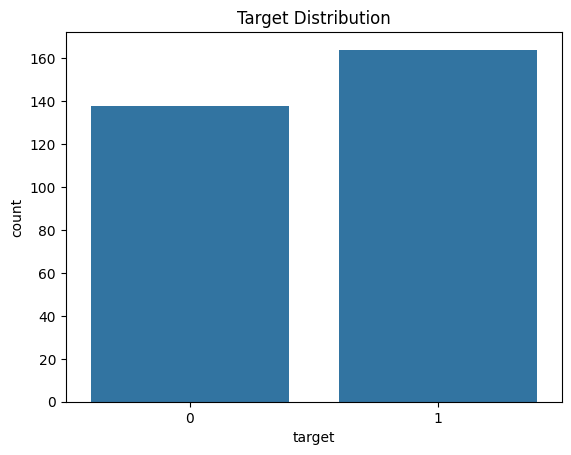

In [6]:
sns.countplot(x=df["target"])

plt.title("Target Distribution")
plt.show()

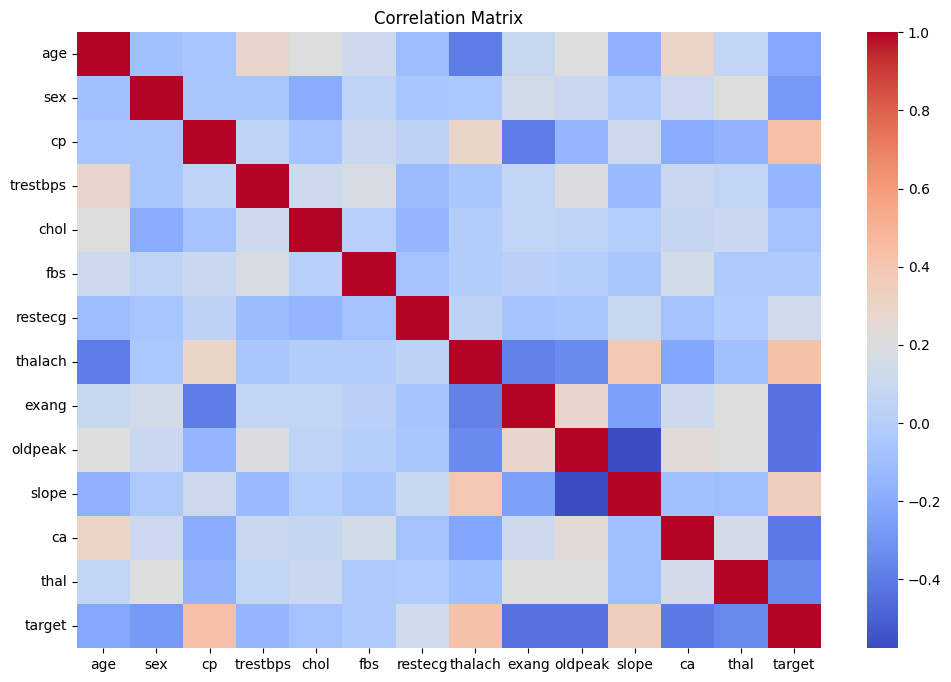

In [7]:
plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

# SECTION 4 — Data Preprocessing

In [8]:
X = df.drop(columns=["target"])
y = df["target"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

# SECTION 5 — Train Models

In [10]:
models = {
    "logistic_regression": LogisticRegression(),
    "random_forest_classifier": RandomForestClassifier(),
    "svc": SVC(probability=True),
    "k_neighbors_classifier": KNeighborsClassifier(),
    "gaussian_nb": GaussianNB(),
}

In [11]:
from cobra.combine_classifier import CombineClassifier

results = {}

combined_classifier = CombineClassifier(
    estimators=models.keys(),
    random_state=42,
)
start_fit = time.perf_counter()
combined_classifier.fit(X_train, y_train)
fit_time = time.perf_counter() - start_fit

start_pred = time.perf_counter()
y_pred_combine = combined_classifier.predict(X_test)
predict_time = time.perf_counter() - start_pred

metrics_combine = evaluate_classification(y_test, y_pred_combine)
results["combine_classifier"] = metrics_combine
print(f"Results for combine_classifier: {metrics_combine}\n")
print(f"Time computing : fit {fit_time}, predict {predict_time}")

search: 100%|██████████| 300/300 [00:00<00:00, 943.76it/s]

Results for combine_classifier: {'Accuracy': 0.7868852459016393, 'Precision': 0.7866173791921139, 'Recall': 0.7868852459016393, 'F1 Score': 0.7865382476588741}

Time computing : fit 0.6947468329890398, predict 0.006244250005693175


In [12]:
combined_classifier.optimization_outputs_

{'method': 'grid',
 'optimizer': 'grid',
 'bandwidth': 4.950337792642141,
 'score': np.float64(0.14966666666666667),
 'history':      iter     score      risk  bandwidth
 0       0  0.404667  0.404667   0.001000
 1       1  0.404667  0.404667   0.034441
 2       2  0.404667  0.404667   0.067883
 3       3  0.404667  0.404667   0.101324
 4       4  0.404667  0.404667   0.134766
 ..    ...       ...       ...        ...
 295   295  0.158000  0.158000   9.866234
 296   296  0.158000  0.158000   9.899676
 297   297  0.158000  0.158000   9.933117
 298   298  0.158000  0.158000   9.966559
 299   299  0.158000  0.158000  10.000000
 
 [300 rows x 4 columns]}

In [13]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = evaluate_classification(y_test, y_pred)
    results[name] = metrics

In [14]:
results_df = pd.DataFrame(results).T
results_df.sort_values(by="Accuracy", ascending=False)

,Accuracy,Precision,Recall,F1 Score
logistic_regression,0.803279,0.803531,0.803279,0.802529
combine_classifier,0.786885,0.786617,0.786885,0.786538
random_forest_classifier,0.786885,0.787769,0.786885,0.787115
gaussian_nb,0.786885,0.791380,0.786885,0.787229
k_neighbors_classifier,0.622951,0.622058,0.622951,0.622337
svc,0.606557,0.605278,0.606557,0.595038


<Axes: xlabel='bandwidth', ylabel='score'>

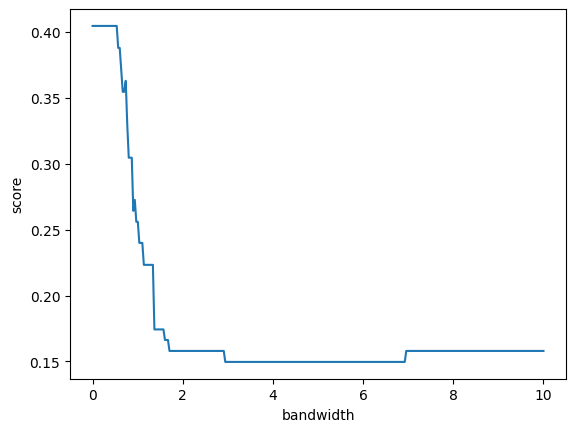

In [15]:
df_output = combined_classifier.optimization_outputs_['history']
sns.lineplot(df_output, x='bandwidth', y='score')

# SECTION 6 — External training

In [16]:
X_base, X_agg, y_base, y_agg = train_test_split(
    X_train,
    y_train,
    test_size=0.5,
    random_state=42,
    stratify=y_train
)

fit_models = {}
for name, model in models.items():
    model.fit(X_base, y_base)
    fit_models[name] = model

P_agg = np.column_stack([
    m.predict(X_agg)
    for m in fit_models.values()
])

P_test = np.column_stack([
    m.predict(X_test)
    for m in fit_models.values()
])

combined = CombineClassifier(
    estimators=fit_models.keys(),
    random_state=42,
)

combined.fit(
    X=P_agg,
    y=y_agg,
    as_predictions=True
)

y_pred = combined.predict(
    X=P_test
)

metrics_combine = evaluate_classification(y_test, y_pred)
metrics_combine


search: 100%|██████████| 300/300 [00:00<00:00, 951.87it/s]


{'Accuracy': 0.8524590163934426,
 'Precision': 0.8524411586128076,
 'Recall': 0.8524590163934426,
 'F1 Score': 0.8522187868407589}

# SECTION 7 — Run Experiments

In [17]:
results_df = pd.DataFrame(results).T
results_df.sort_values(by="Accuracy", ascending=False)

,Accuracy,Precision,Recall,F1 Score
logistic_regression,0.803279,0.803531,0.803279,0.802529
combine_classifier,0.786885,0.786617,0.786885,0.786538
random_forest_classifier,0.786885,0.787769,0.786885,0.787115
gaussian_nb,0.786885,0.791380,0.786885,0.787229
k_neighbors_classifier,0.622951,0.622058,0.622951,0.622337
svc,0.606557,0.605278,0.606557,0.595038


# SECTION 8 — Experiements

In [18]:
from cobra.combine_classifier import CombineClassifier
from kfc_procedure.kfc import KFCClassifier
models = {
    "logistic_regression": LogisticRegression(),
    "random_forest_classifier": RandomForestClassifier(),
    "svc": SVC(probability=True),
    "k_neighbors_classifier": KNeighborsClassifier(),
    "gaussian_nb": GaussianNB(),
}
scaler = MinMaxScaler(feature_range=(0.05, 0.95))
seeds = [0, 42, 100, 2024, 999]
results = []

In [52]:
for seed in seeds:
    print(f"Running seed = {seed}")
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=seed,
    )

    print("Running base models...")
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics = evaluate_classification(y_test, y_pred)
        response = {
            "model": name,
            "seed": seed,
            **metrics
        }
        results.append(response)
    
    # implement combine classifier
    print("Running combined classifier...")
    combined = CombineClassifier(
        estimators=models.keys(),
        random_state=seed,
    )

    combined.fit(X_train, y_train)
    y_pred = combined.predict(X_test)
    metrics = evaluate_classification(y_test, y_pred)
    response = {
        "model" : "combined classifier",
        "seed" : seed,
        **metrics
    }
    results.append(response)

    # implement kfc
    # scale value to positive
    print("Running KFC classifier...")
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    kfc = KFCClassifier(
        divergences=['euclidean', 'gkl', 'is', "logistic"],
        local_model="logistic_regression",
        combiner="combiner_classifier",
        n_clusters=2,
        random_state=seed
    )

    kfc.fit(X_train_scaled, y_train)
    y_pred = kfc.predict(X_test_scaled)
    metrics = evaluate_classification(y_test, y_pred)
    response = {
        "model" : "kfc",
        "seed" : seed,
        **metrics
    }
    results.append(response)
    

Running seed = 0
Running base models...
Running combined classifier...


search: 100%|██████████| 300/300 [00:00<00:00, 989.65it/s]


Running KFC classifier...
P_l : (121, 4), y_l : (121,)


search: 100%|██████████| 300/300 [00:00<00:00, 985.95it/s]


Running seed = 42
Running base models...
Running combined classifier...


...

search: 100%|██████████| 300/300 [00:00<00:00, 957.04it/s]


Running seed = 999
Running base models...
Running combined classifier...


search: 100%|██████████| 300/300 [00:00<00:00, 985.07it/s]


Running KFC classifier...
P_l : (121, 4), y_l : (121,)


search: 100%|██████████| 300/300 [00:00<00:00, 967.11it/s]


In [53]:
summary = (
    pd.DataFrame(results)
    .groupby("model")[["Accuracy", "Precision", "Recall", "F1 Score"]]
    .agg(["mean", "std"])
    .sort_values(("Accuracy", "mean"), ascending=False)
)
summary

Accuracy           Precision              Recall  \
                              mean       std      mean       std      mean   
model                                                                        
gaussian_nb               0.826935  0.028726  0.829311  0.028724  0.826935   
logistic_regression       0.820295  0.038620  0.825120  0.036862  0.820295   
random_forest_classifier  0.817182  0.042335  0.818736  0.041982  0.817182   
combined classifier       0.811579  0.038120  0.814328  0.037692  0.811579   
kfc                       0.747452  0.133344  0.709353  0.224312  0.747452   
k_neighbors_classifier    0.645777  0.032620  0.647397  0.035488  0.645777   
svc                       0.640382  0.032506  0.647133  0.038577  0.640382   

                                    F1 Score            
                               std      mean       std  
model                                                   
gaussian_nb               0.028726  0.826798  0.028194  
logistic_regression       0.038620  0.818171  0.039998  
random_forest_classifier  0.042335  0.816256  0.042840  
combined classifier       0.038120  0.810147  0.038724  
kfc                       0.133344  0.719003  0.194327  
k_neighbors_classifier    0.032620  0.639799  0.031633  
svc                       0.032506  0.625630  0.032614